<a href="https://colab.research.google.com/github/DiplovRawal/AI-SEM-6/blob/Worksheet/Worksheet_02_Softmax_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 2: Image Classification Using Softmax Regression

**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Topic:** Image Classification Using Softmax Regression (MNIST Dataset)


## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Exercise - Building Softmax Regression for MNIST

### 2.1 Decision Function

#### Softmax Function
The softmax function maps a vector of real numbers to a probability distribution over K classes:

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}, \quad \text{for } i = 1, 2, \ldots, K$$


In [2]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
            - m is the number of samples.
            - n is the number of classes.

    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n), where
            each row sums to 1 and represents the probability distribution over classes.

    Notes:
        - The input to softmax is typically computed as: z = XW + b.
        - Uses numerical stabilization by subtracting the max value per row.
    """
    # Numerical stabilization: subtract max per row to prevent overflow
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# ---- Test Case ----
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

# Verify if the sum of probabilities for each row is 1
row_sums = np.sum(softmax_output, axis=1)

# Assert that the sum of each row is 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")
print(f"Softmax output:\n{softmax_output}")
print(f"Row sums: {row_sums}")


Softmax function passed the test case!
Softmax output:
[[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]
Row sums: [1. 1.]


#### Prediction Function
Assigns class labels by selecting the class with the highest softmax probability.


In [3]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        numpy.ndarray: Predicted class labels of shape (n,).
    """
    z = np.dot(X, W) + b          # Compute logits: shape (n, c)
    probs = softmax(z)             # Convert to probabilities
    predicted_classes = np.argmax(probs, axis=1)  # Pick class with highest probability
    return predicted_classes


# ---- Test Case ----
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])   # (3 samples, 2 features)
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])      # (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3])                          # (3 classes)

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)


Predicted class labels: [1 1 0]


### 2.2 Loss and Cost Functions

#### Categorical Cross-Entropy Loss

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$


In [4]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss over a batch of samples.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c) or (c,).
        y      (numpy.ndarray): True labels (one-hot encoded) of shape (n, c) or (c,).

    Returns:
        float: Average cross-entropy loss.
    """
    # Clip predictions to avoid log(0) numerical issues
    y_pred_clipped = np.clip(y_pred, 1e-15, 1.0)
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=-1))
    return loss


# ---- Test Case ----
y_true_correct   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct   = np.array([[0.9, 0.05, 0.05],
                              [0.1, 0.85, 0.05],
                              [0.05, 0.1, 0.85]])

y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1,  0.05, 0.85],
                              [0.85, 0.1,  0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)

print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")


Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


#### Cost Function (Average Cross-Entropy over Dataset)

In [5]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        float: Average softmax cost over all samples.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b          # Logits: (n, c)
    y_pred = softmax(z)            # Probabilities: (n, c)

    # Clip to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1.0)
    total_loss = -np.sum(y * np.log(y_pred_clipped))

    return total_loss / n


# ---- Test Case ----
X_correct   = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct   = np.array([[1, 0], [0, 1]])
W_correct   = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct   = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

print(f"Cost for correct prediction:   {cost_correct:.4f}")
print(f"Cost for incorrect prediction: {cost_incorrect:.4f}")
print("Test passed!")


Cost for correct prediction:   0.0006
Cost for incorrect prediction: 0.2993
Test passed!


### 2.3 Gradient Descent

#### Gradients of the Cross-Entropy Loss

$$\frac{\partial \mathcal{L}}{\partial W_k} = -\frac{1}{n} \sum_{i=1}^{n} (y_{i,k} - \hat{y}_{i,k})\, x_i$$

$$\frac{\partial \mathcal{L}}{\partial b_k} = -\frac{1}{n} \sum_{i=1}^{n} (y_{i,k} - \hat{y}_{i,k})$$


In [6]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function w.r.t. weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        tuple: (grad_W, grad_b) — gradients w.r.t. weights (d, c) and biases (c,).
    """
    n = X.shape[0]
    z = np.dot(X, W) + b          # Logits: (n, c)
    y_pred = softmax(z)            # Softmax probabilities: (n, c)

    diff = y_pred - y              # Error matrix: (n, c)

    grad_W = np.dot(X.T, diff) / n   # (d, c)
    grad_b = np.sum(diff, axis=0) / n  # (c,)

    return grad_W, grad_b


# ---- Test Case ----
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manual reference
z_test_ref   = np.dot(X_test, W_test) + b_test
y_pred_ref   = softmax(z_test_ref)
grad_W_manual = np.dot(X_test.T, (y_pred_ref - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_ref - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), f"Gradient W mismatch.\nExpected:\n{grad_W_manual}\nGot:\n{grad_W}"
assert np.allclose(grad_b, grad_b_manual), f"Gradient b mismatch.\nExpected:\n{grad_b_manual}\nGot:\n{grad_b}"

print("Gradient w.r.t. W:\n", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")


Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


#### Gradient Descent Algorithm

In [7]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimise weights and biases for softmax regression.

    Parameters:
        X        (numpy.ndarray): Feature matrix (n, d).
        y        (numpy.ndarray): One-hot encoded labels (n, c).
        W        (numpy.ndarray): Initial weight matrix (d, c).
        b        (numpy.ndarray): Initial bias vector (c,).
        alpha    (float)        : Learning rate.
        n_iter   (int)          : Number of iterations.
        show_cost(bool)         : Print cost at every 100 iterations if True.

    Returns:
        tuple: (W, b, cost_history)
    """
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Record cost
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # Optionally print cost
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i:4d} | Cost: {current_cost:.6f}")

    return W, b, cost_history


### 2.4 Preparing the Dataset

#### Question 1: Is extracting pixel values sufficient for effective feature extraction? Why or why not?

**Answer:** Extracting raw pixel values is a reasonable baseline for simple datasets like MNIST, but it is not always sufficient for more complex tasks. Pixel values are a direct but noisy representation; they are sensitive to variations in lighting, rotation, scaling, and translation. More sophisticated feature extraction methods — such as edge detection, HOG (Histogram of Oriented Gradients), or learned representations from convolutional neural networks — can capture structural and spatial patterns that raw pixels miss. For MNIST specifically, pixel features work reasonably well because the images are already normalised, centred, and of uniform size, but even here, CNN-based models significantly outperform a pixel-based softmax classifier.


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


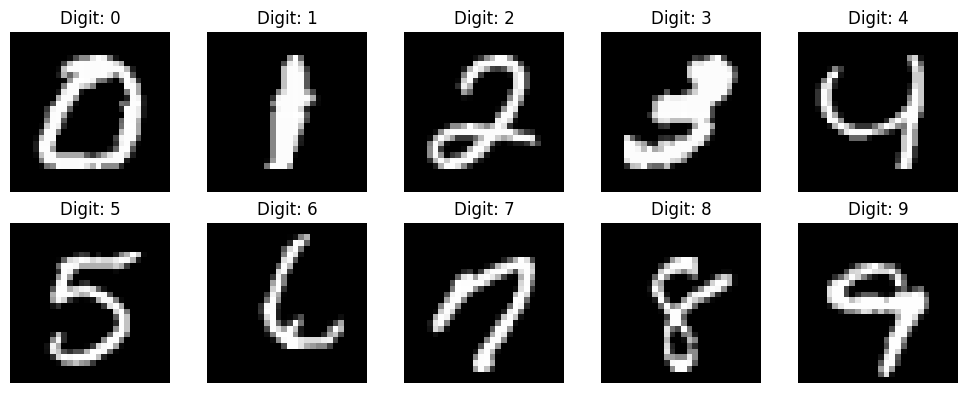

Training set : X=(15999, 784), y=(15999,)
Test set     : X=(4000, 784),  y=(4000,)


In [14]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test


csv_file = '/content/sample_data/mnist_train_small.csv'

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)

print(f"Training set : X={X_train.shape}, y={y_train.shape}")
print(f"Test set     : X={X_test.shape},  y={y_test.shape}")

### 2.5 Training the Softmax Regression Model

Move forward: Dimension of Feature Matrix X and label vector y matched.
Iteration    0 | Cost: 2.191686
Iteration  100 | Cost: 0.596407
Iteration  200 | Cost: 0.477427
Iteration  300 | Cost: 0.427784
Iteration  400 | Cost: 0.398864
Iteration  500 | Cost: 0.379299
Iteration  600 | Cost: 0.364881
Iteration  700 | Cost: 0.353653
Iteration  800 | Cost: 0.344561
Iteration  900 | Cost: 0.336986
Iteration  999 | Cost: 0.330594


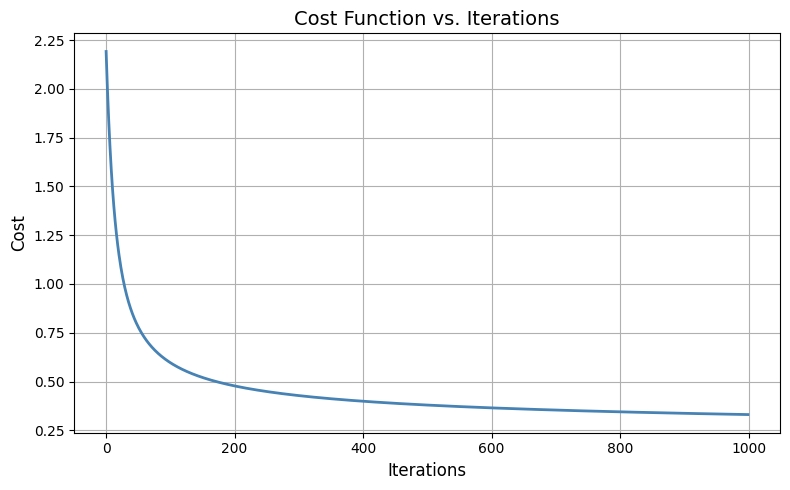

In [15]:
# Shape check
assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]   # Number of features
c = y_train.shape[1]   # Number of classes

# Initialise parameters
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha  = 0.1
n_iter = 1000

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot Cost vs Iterations
plt.figure(figsize=(8, 5))
plt.plot(cost_history, color='steelblue', linewidth=2)
plt.title('Cost Function vs. Iterations', fontsize=14)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


### 2.6 Evaluating Model Performance


Confusion Matrix:
[[359   0   3   1   1   3   4   1   5   0]
 [  0 426   1   4   1   2   0   1   1   0]
 [  3   1 346   2  10   1   6   7   9   5]
 [  3   1  11 358   0  15   0   5   7   6]
 [  1   2   6   1 367   0   7   1   1  15]
 [  4   4   5  22   3 277   8   1  13   4]
 [  1   1  13   1   4   9 380   0   3   0]
 [  2   4   6   3   4   0   1 401   3  14]
 [  4   9   9  10   3  23   2   5 317   2]
 [  2   5   1   5  20   4   0   7   5 366]]
Precision : 0.90
Recall    : 0.90
F1-Score  : 0.90


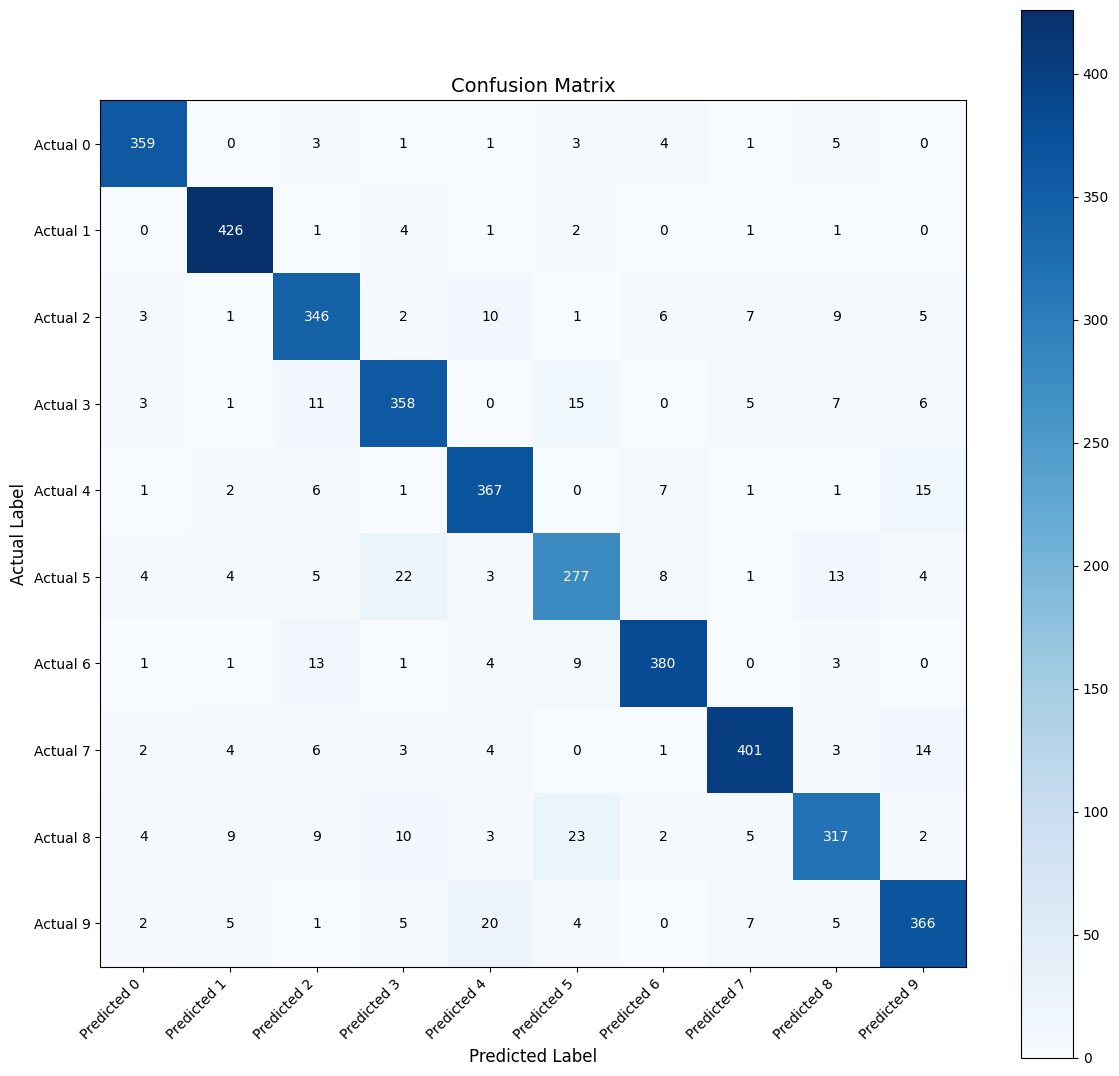

In [17]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
        y_true (numpy.ndarray): True labels
        y_pred (numpy.ndarray): Predicted labels

    Returns:
        tuple: Confusion matrix, precision, recall, F1 score
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1


# Predict on test set
y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")

# Visualise Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)], rotation=45, ha='right')
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()


## 3. Exercise - Linear Separability and Logistic Regression

### Question 2 — Interpretation of Output

The four plots show how Logistic Regression draws a **decision boundary** on two datasets:

1. **Linearly Separable Data (Training & Testing):** The boundary is a clean straight line that neatly divides the two classes. Both the training and testing plots look very similar, indicating the model generalises well — it has learned a boundary that captures the true structure of the data.

2. **Non-Linearly Separable Data (Training & Testing):** The data consists of two concentric circles, so the classes are interleaved and cannot be separated by a straight line. Logistic Regression still draws a linear boundary, which cuts through both classes poorly. The model fails to capture the circular structure of the data, resulting in substantial misclassification on both the training and test sets. This demonstrates the fundamental limitation of linear classifiers on non-linearly separable problems.

**Key takeaway:** Logistic Regression works well when data is linearly separable but struggles when the decision boundary must be non-linear. Non-linear problems require either feature engineering (e.g., adding polynomial features) or non-linear models such as SVMs with RBF kernels or neural networks.

---

### Question 3 — Challenges Faced

- **Understanding `make_circles`:** At first glance it is not obvious that the two concentric rings are truly inseparable by a line; plotting the data first helped clarify this.
- **Mesh grid resolution:** Choosing the step size `h = 0.02` is a trade-off between visualisation quality and computation time; a coarser grid runs faster but produces a jagged boundary.
- **Colour-map consistency:** Ensuring the same `cmap` is used for both `contourf` and `scatter` so that class colours match between the decision regions and the data points requires care.
- **Subplot layout:** Arranging four plots in a 2×2 grid with meaningful titles and axis labels takes attention to indexing (`axes[row, col]`).


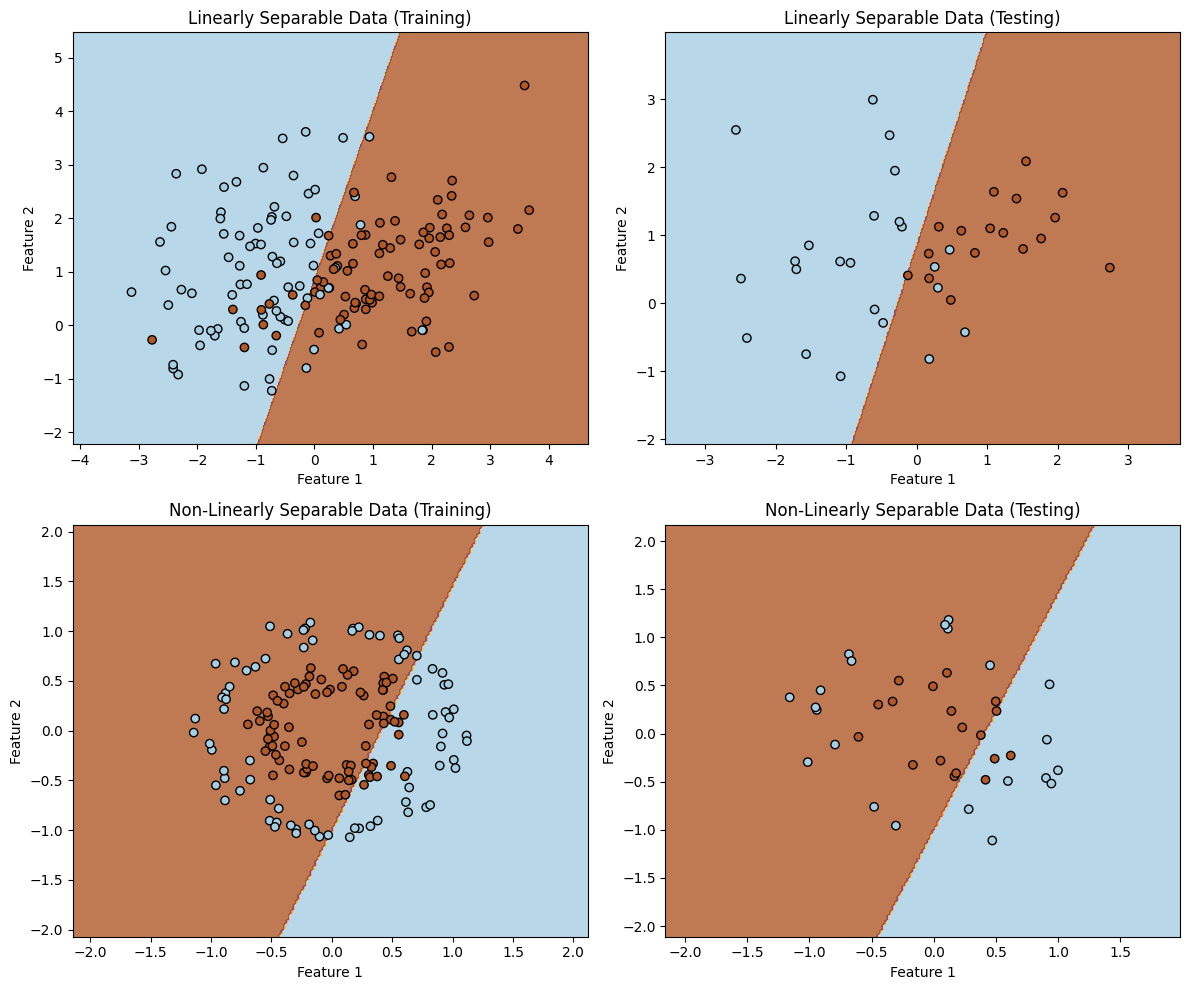

Decision boundary plots saved to decision_boundaries.png


In [16]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# --- Linearly Separable Dataset ---
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# --- Non-Linearly Separable Dataset (Circles) ---
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)


# --- Decision Boundary Plot ---
def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')

plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')

plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear,
                       'Non-Linearly Separable Data (Training)')

plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear,
                       'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision boundary plots saved to decision_boundaries.png")
